# ch314 — Convolutional Neural Networks

## 1. Why convolutions?

A fully connected layer on a 32×32 image has $32 \times 32 \times d_{\text{out}}$ weights
per layer. For a 256×256 image this becomes intractable, and the model would have to relearn
the same edge detector at every pixel position — ignoring the spatial structure of images.

**Convolutions** exploit two structural properties of natural images:
- **Translation equivariance**: the same filter applies everywhere in the image.
- **Local connectivity**: nearby pixels are more related than distant pixels.

A conv layer learns a small filter $W \in \mathbb{R}^{F \times C \times k \times k}$ and
slides it across the image, producing a feature map at every spatial position:

$$y[f, i, j] = \sum_c \sum_p \sum_q W[f, c, p, q] \cdot x[c, i+p, j+q] + b[f]$$

*(Linear transformations: ch154. Matrix operations: ch151. Function composition: ch054.)*

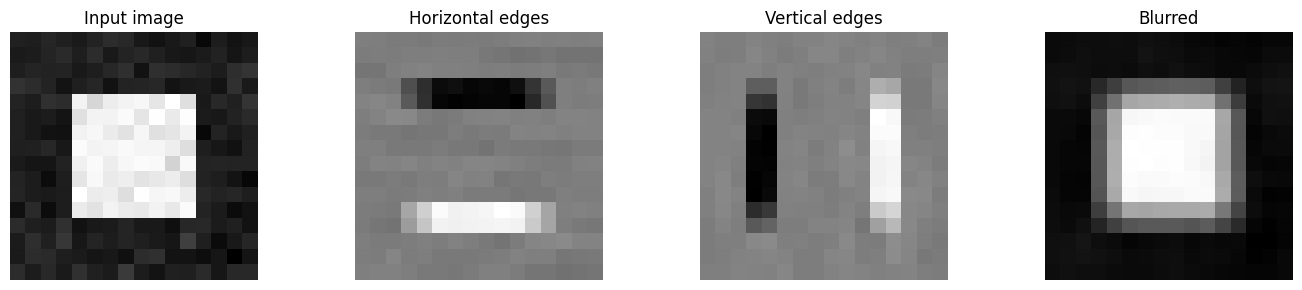

Output shape (same spatial size with padding=1): (1, 16, 16)


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def conv2d_naive(X: np.ndarray, W: np.ndarray, b: np.ndarray,
                 stride: int = 1, padding: int = 0) -> np.ndarray:
    """
    Pure NumPy 2D convolution (cross-correlation).
    X: (C, H, W)   W: (F, C, kH, kW)   b: (F,)
    Returns: (F, Ho, Wo)
    """
    C, H, Ww = X.shape
    F, _, kH, kW = W.shape

    if padding > 0:
        X = np.pad(X, ((0, 0), (padding, padding), (padding, padding)))

    Ho = (X.shape[1] - kH) // stride + 1
    Wo = (X.shape[2] - kW) // stride + 1
    out = np.zeros((F, Ho, Wo))

    for f in range(F):
        for i in range(Ho):
            for j in range(Wo):
                patch = X[:, i*stride:i*stride+kH, j*stride:j*stride+kW]
                out[f, i, j] = np.sum(W[f] * patch) + b[f]
    return out


# ── Visualise what convolutions detect ──
rng = np.random.default_rng(0)
img = np.zeros((1, 16, 16))
img[0, 4:12, 4:12] = 1.0  # white square on black background
img += rng.normal(0, 0.05, img.shape)

# Hand-crafted filters
W_edge_h = np.array([[[[ 1, 1, 1],[ 0, 0, 0],[-1,-1,-1]]]], dtype=float)  # horizontal edge
W_edge_v = np.array([[[[ 1, 0,-1],[ 1, 0,-1],[ 1, 0,-1]]]], dtype=float)  # vertical edge
W_blur   = np.ones((1,1,3,3)) / 9                                           # box blur

b_zero = np.zeros(1)

out_h = conv2d_naive(img, W_edge_h, b_zero, padding=1)
out_v = conv2d_naive(img, W_edge_v, b_zero, padding=1)
out_b = conv2d_naive(img, W_blur,   b_zero, padding=1)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, data, title in zip(axes,
        [img[0], out_h[0], out_v[0], out_b[0]],
        ['Input image', 'Horizontal edges', 'Vertical edges', 'Blurred']):
    ax.imshow(data, cmap='gray'); ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.savefig('ch314_conv_filters.png', dpi=120)
plt.show()
print("Output shape (same spatial size with padding=1):", out_h.shape)

In [2]:
# Batched conv using im2col — orders of magnitude faster
def im2col(X: np.ndarray, kH: int, kW: int, stride: int, padding: int) -> np.ndarray:
    """X: (B, C, H, W). Returns (B*Ho*Wo, C*kH*kW) column matrix."""
    B, C, H, W = X.shape
    if padding > 0:
        X = np.pad(X, ((0,0),(0,0),(padding,padding),(padding,padding)))
    Ho = (X.shape[2] - kH) // stride + 1
    Wo = (X.shape[3] - kW) // stride + 1
    cols = np.zeros((B, C, kH, kW, Ho, Wo))
    for i in range(kH):
        for j in range(kW):
            cols[:, :, i, j, :, :] = X[:, :, i:i+Ho*stride:stride, j:j+Wo*stride:stride]
    return cols.transpose(0,4,5,1,2,3).reshape(B*Ho*Wo, C*kH*kW), Ho, Wo

def conv2d_batch(X: np.ndarray, W: np.ndarray, b: np.ndarray,
                 stride: int = 1, padding: int = 0) -> np.ndarray:
    """X: (B,C,H,W), W: (F,C,kH,kW). Returns (B,F,Ho,Wo)."""
    B, C, H, Ww = X.shape
    F, _, kH, kW = W.shape
    col, Ho, Wo = im2col(X, kH, kW, stride, padding)
    W_col = W.reshape(F, -1)            # (F, C*kH*kW)
    out = (col @ W_col.T + b).T        # (F, B*Ho*Wo)
    return out.reshape(F, B, Ho, Wo).transpose(1, 0, 2, 3)

# Compare naive vs batched
B = 4; C = 3; H = 16; W = 16; F = 8; k = 3
rng = np.random.default_rng(1)
X_b = rng.normal(0, 1, (B, C, H, W))
W_b = rng.normal(0, 0.1, (F, C, k, k))
b_b = np.zeros(F)

out_batch = conv2d_batch(X_b, W_b, b_b, stride=1, padding=1)
print("Batched conv output shape:", out_batch.shape)
print(f"Expected: ({B}, {F}, {H}, {W})")

# Verify against naive on first sample
out_naive = conv2d_naive(X_b[0], W_b, b_b, padding=1)
max_diff = np.abs(out_batch[0] - out_naive).max()
print(f"Max diff between naive and batched: {max_diff:.2e} (should be ~0)")

Batched conv output shape: (4, 8, 16, 16)
Expected: (4, 8, 16, 16)
Max diff between naive and batched: 4.44e-16 (should be ~0)


## 2. Receptive field

After $L$ conv layers each with kernel size $k$, a single output neuron depends on a
$(1 + L(k-1)) \times (1 + L(k-1))$ region of the input — the **receptive field**.
Dilated convolutions expand the receptive field without adding parameters.

## 3. Parameter sharing

A single filter of size $k \times k \times C$ has $k^2 C$ parameters — the same filter is
applied at every spatial location. For a 3×3×3 filter on a 224×224 image, this is
27 parameters vs $224 \times 224 \times 3 = 150{,}528$ for a fully connected connection.

## 4. Summary

- Conv layers slide a small filter over the input, producing a feature map.
- Translation equivariance: the same filter fires wherever the pattern occurs.
- im2col reshapes the problem into a matrix multiply — GPU-efficient.
- Receptive field grows with depth; dilated convs expand it without extra parameters.

## 5. Forward and backward references

**Used here:** matrix multiply *(ch153)*, linear transformations *(ch154)*, function composition *(ch054)*.

**This will reappear in ch315 — Pooling and Receptive Fields**, where spatial downsampling
is added after convolution, and in ch334 — Project: Neural Net from Scratch, which uses
conv layers as the core building block.